# dGen Run Comparison — All 48 States

Compares the **policy-minus-baseline increment** between any two dGen runs.
Pick the two runs in the config cell via `A_KEY` / `B_KEY` from the `RUNS` registry:

- **`old_tariffs`** — original 2016-era utility rates
- **`updated_immediate`** — URDB-updated tariffs, policy = $1/W immediately in 2026
- **`linear_to_1w`** — URDB-updated tariffs, policy = linear ramp to $1/W by 2036

All metrics are (policy − baseline) to isolate net new adoption driven by the policy.
`A` is the reference (left/"_old" internally), `B` is the comparison (right/"_new").

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DRIVE = "/Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025"

# ── Run registry: every dGen run available to compare ───────────────────────
# label     -> shown in plots/tables
# xlsx      -> summary workbook (relative to DRIVE)
# county_dir + run_id -> used by the county-level export cells
RUNS = {
    "old_tariffs": {
        "label": "Old tariffs (2016-era)",
        "xlsx":  "Results/Raw/run_all_states_net_savings_add_itc — Old Tariffs (2016-era rates) — All 50 States.xlsx",
        "county_dir": "Results/Raw",
        "run_id": "run_all_states_net_savings_add_itc",
    },
    "updated_immediate": {
        "label": "Immediate $1/W",
        "xlsx":  "Results/Updated tariffs/run_all_states_updated_tariffs — Updated Tariffs — All 48 States.xlsx",
        "county_dir": "Results/Updated tariffs",
        "run_id": "run_all_states_updated_tariffs",
    },
    "linear_to_1w": {
        "label": "Linear to $1/W by 2036",
        # filename has "$1 per W" (no slash) because the analysis notebook's RUN_LABEL
        # feeds os.path.join and a "/" would be read as a directory separator.
        "xlsx":  "Results/Updated tariffs/run_all_states_linear_to_1w — Linear to $1 per W by 2036 — All 48 States.xlsx",
        "county_dir": "Results/Updated tariffs",
        "run_id": "run_all_states_linear_to_1w",
    },
}

# ── Pick the two runs to compare ────────────────────────────────────────────
A_KEY = "updated_immediate"   # reference  (plotted first, "_old" internal suffix)
B_KEY = "linear_to_1w"        # comparison (plotted second, "_new" internal suffix)

A, B = RUNS[A_KEY], RUNS[B_KEY]
A_LABEL, B_LABEL = A["label"], B["label"]
OLD_FILE = os.path.join(DRIVE, A["xlsx"])
NEW_FILE = os.path.join(DRIVE, B["xlsx"])
COMPARISON = f"{A_LABEL} vs {B_LABEL}"

# The avg $/kWh columns (old 2016 vs updated) only make sense when the two runs
# differ by TARIFF regime. For same-tariff comparisons (e.g. immediate vs linear
# $1/W) they'd be identical, so the state table drops them.
SHOW_TARIFF_PRICES = {A_KEY, B_KEY} == {"old_tariffs", "updated_immediate"}

STATES = ["AL","AR","AZ","CA","CO","CT","DE","FL","GA","IA","ID","IL","IN","KS","KY",
          "LA","MA","MD","ME","MI","MN","MO","MS","MT","NC","ND","NE","NH","NJ","NM",
          "NV","NY","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VA","VT","WA","WI","WV","WY"]

print(f"Comparison: {COMPARISON}")
print(f"  A (reference):  {A_LABEL}\n     {OLD_FILE}")
print(f"  B (comparison): {B_LABEL}\n     {NEW_FILE}")
print(f"  Tariff-price columns in state table: {SHOW_TARIFF_PRICES}")

Comparison: Immediate $1/W vs Linear to $1/W by 2036
  A (reference):  Immediate $1/W
     /Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025/Results/Updated tariffs/run_all_states_updated_tariffs — Updated Tariffs — All 48 States.xlsx
  B (comparison): Linear to $1/W by 2036
     /Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025/Results/Updated tariffs/run_all_states_linear_to_1w — Linear to $1 per W by 2036 — All 48 States.xlsx
  Tariff-price columns in state table: False


In [4]:
def load_sheet(path, sheet):
    return pd.read_excel(path, sheet_name=sheet)

def get_increment(df, states, value_cols):
    """Return policy - baseline for each state/year and value column."""
    df = df[df["state_abbr"].isin(states)].copy()
    pol = df[df["scenario"] == "policy"].set_index(["state_abbr", "year"])[value_cols]
    bas = df[df["scenario"] == "baseline"].set_index(["state_abbr", "year"])[value_cols]
    return (pol - bas).reset_index()

old_xl = pd.ExcelFile(OLD_FILE)
new_xl = pd.ExcelFile(NEW_FILE)

old_totals      = load_sheet(OLD_FILE, "totals")
new_totals      = load_sheet(NEW_FILE, "totals")
old_cum_savings = load_sheet(OLD_FILE, "cumulative_bill_savings") if "cumulative_bill_savings" in old_xl.sheet_names else None
new_cum_savings = load_sheet(NEW_FILE, "cumulative_bill_savings") if "cumulative_bill_savings" in new_xl.sheet_names else None
old_lifetime    = load_sheet(OLD_FILE, "lifetime_totals") if "lifetime_totals" in old_xl.sheet_names else None
new_lifetime    = load_sheet(NEW_FILE, "lifetime_totals") if "lifetime_totals" in new_xl.sheet_names else None

print(f"{A_LABEL} — states available:", sorted(old_totals[old_totals['state_abbr'].isin(STATES)]['state_abbr'].unique()))
print(f"{B_LABEL} — states available:", sorted(new_totals[new_totals['state_abbr'].isin(STATES)]['state_abbr'].unique()))
print(f"cumulative_bill_savings: {A_LABEL}={'yes' if old_cum_savings is not None else 'no'}, {B_LABEL}={'yes' if new_cum_savings is not None else 'no'}")
print(f"lifetime_totals:         {A_LABEL}={'yes' if old_lifetime is not None else 'no'}, {B_LABEL}={'yes' if new_lifetime is not None else 'no'}")

Immediate $1/W — states available: ['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
Linear to $1/W by 2036 — states available: ['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
cumulative_bill_savings: Immediate $1/W=yes, Linear to $1/W by 2036=yes
lifetime_totals:         Immediate $1/W=yes, Linear to $1/W by 2036=yes


In [5]:
# --- Incremental adopters & capacity by state ---
adopt_cols = ["new_adopters", "number_of_adopters", "system_kw_cum"]
old_inc = get_increment(old_totals, STATES, adopt_cols)
new_inc = get_increment(new_totals, STATES, adopt_cols)

comp = old_inc.merge(new_inc, on=["state_abbr", "year"], suffixes=("_old", "_new"))
comp["adopters_pct_change"] = (
    (comp["number_of_adopters_new"] - comp["number_of_adopters_old"])
    / comp["number_of_adopters_old"].abs() * 100
).round(1)

print("Policy-minus-baseline increment by state — 2040:")
summary_2040 = comp[comp["year"] == 2040][[
    "state_abbr", "number_of_adopters_old", "number_of_adopters_new", "adopters_pct_change",
    "system_kw_cum_old", "system_kw_cum_new"
]].copy()
summary_2040["capacity_mw_old"] = (summary_2040["system_kw_cum_old"] / 1000).round(1)
summary_2040["capacity_mw_new"] = (summary_2040["system_kw_cum_new"] / 1000).round(1)
print(summary_2040[["state_abbr","number_of_adopters_old","number_of_adopters_new",
                     "adopters_pct_change","capacity_mw_old","capacity_mw_new"]].to_string(index=False))

Policy-minus-baseline increment by state — 2040:
state_abbr  number_of_adopters_old  number_of_adopters_new  adopters_pct_change  capacity_mw_old  capacity_mw_new
        AL            3.817677e+04            1.004905e+04                -73.7            472.1            132.3
        AR            2.486526e+05            1.063039e+05                -57.2           2943.0           1268.4
        AZ            5.026183e+05            2.470845e+05                -50.8           4518.9           2287.3
        CA            2.916819e+06            1.688298e+06                -42.1          15926.0           9971.1
        CO            5.928277e+05            3.096330e+05                -47.8           4097.0           2210.8
        CT            2.942785e+05            1.588499e+05                -46.0           3211.5           1731.7
        DE            1.035816e+05            5.278302e+04                -49.0           1157.4            563.0
        FL            2.253536e+06     

In [6]:
# --- State-level summary table ---
tbl = summary_2040[["state_abbr",
                    "number_of_adopters_old", "number_of_adopters_new",
                    "capacity_mw_old", "capacity_mw_new"]].copy()

cols   = ["state_abbr"]
rename = {"state_abbr": "State"}

if SHOW_TARIFF_PRICES:
    # Avg $/kWh: all-household weighted average (old 2016 vs updated tariffs).
    # Notebooks/ is 3 levels below repo root: dgen/dgen_os/python/Notebooks/
    DATA_DIR = os.path.abspath(os.path.join(os.path.abspath("."), "..", "..", "..", "data"))
    state_prices = pd.read_csv(os.path.join(DATA_DIR, "state_avg_price_updated.csv"),
                               usecols=["state_abbr", "old_avg_$/kWh", "updated_avg_$/kWh"])
    for col in ["old_avg_$/kWh", "updated_avg_$/kWh"]:
        state_prices[col] = state_prices[col].str.replace("$", "", regex=False).astype(float)
    tbl = tbl.merge(state_prices, on="state_abbr", how="left")
    cols += ["old_avg_$/kWh", "updated_avg_$/kWh"]
    rename.update({"old_avg_$/kWh": "Avg old $/kWh", "updated_avg_$/kWh": "Avg new $/kWh"})

cols += ["number_of_adopters_old", "number_of_adopters_new", "capacity_mw_old", "capacity_mw_new"]
rename.update({
    "number_of_adopters_old": f"Net adopters ({A_LABEL})",
    "number_of_adopters_new": f"Net adopters ({B_LABEL})",
    "capacity_mw_old":        f"Net capacity MW ({A_LABEL})",
    "capacity_mw_new":        f"Net capacity MW ({B_LABEL})",
})

tbl = tbl.sort_values("state_abbr").reset_index(drop=True)[cols].rename(columns=rename)

out_path = os.path.join(DRIVE, f"Results/Updated tariffs/state_comparison_2040_{A_KEY}_vs_{B_KEY}.csv")
tbl.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
tbl

Saved to /Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025/Results/Updated tariffs/state_comparison_2040_updated_immediate_vs_linear_to_1w.csv


,State,Net adopters (Immediate $1/W),Net adopters (Linear to $1/W by 2036),Net capacity MW (Immediate $1/W),Net capacity MW (Linear to $1/W by 2036)
0,AL,3.817677e+04,1.004905e+04,472.1,132.3
1,AR,2.486526e+05,1.063039e+05,2943.0,1268.4
2,AZ,5.026183e+05,2.470845e+05,4518.9,2287.3
3,CA,2.916819e+06,1.688298e+06,15926.0,9971.1
4,CO,5.928277e+05,3.096330e+05,4097.0,2210.8
5,CT,2.942785e+05,1.588499e+05,3211.5,1731.7
6,DE,1.035816e+05,5.278302e+04,1157.4,563.0
7,FL,2.253536e+06,1.166315e+06,36595.1,18931.8
8,GA,4.578767e+05,2.143402e+05,5938.1,2811.8
9,IA,3.113515e+05,1.412694e+05,2816.0,1274.7


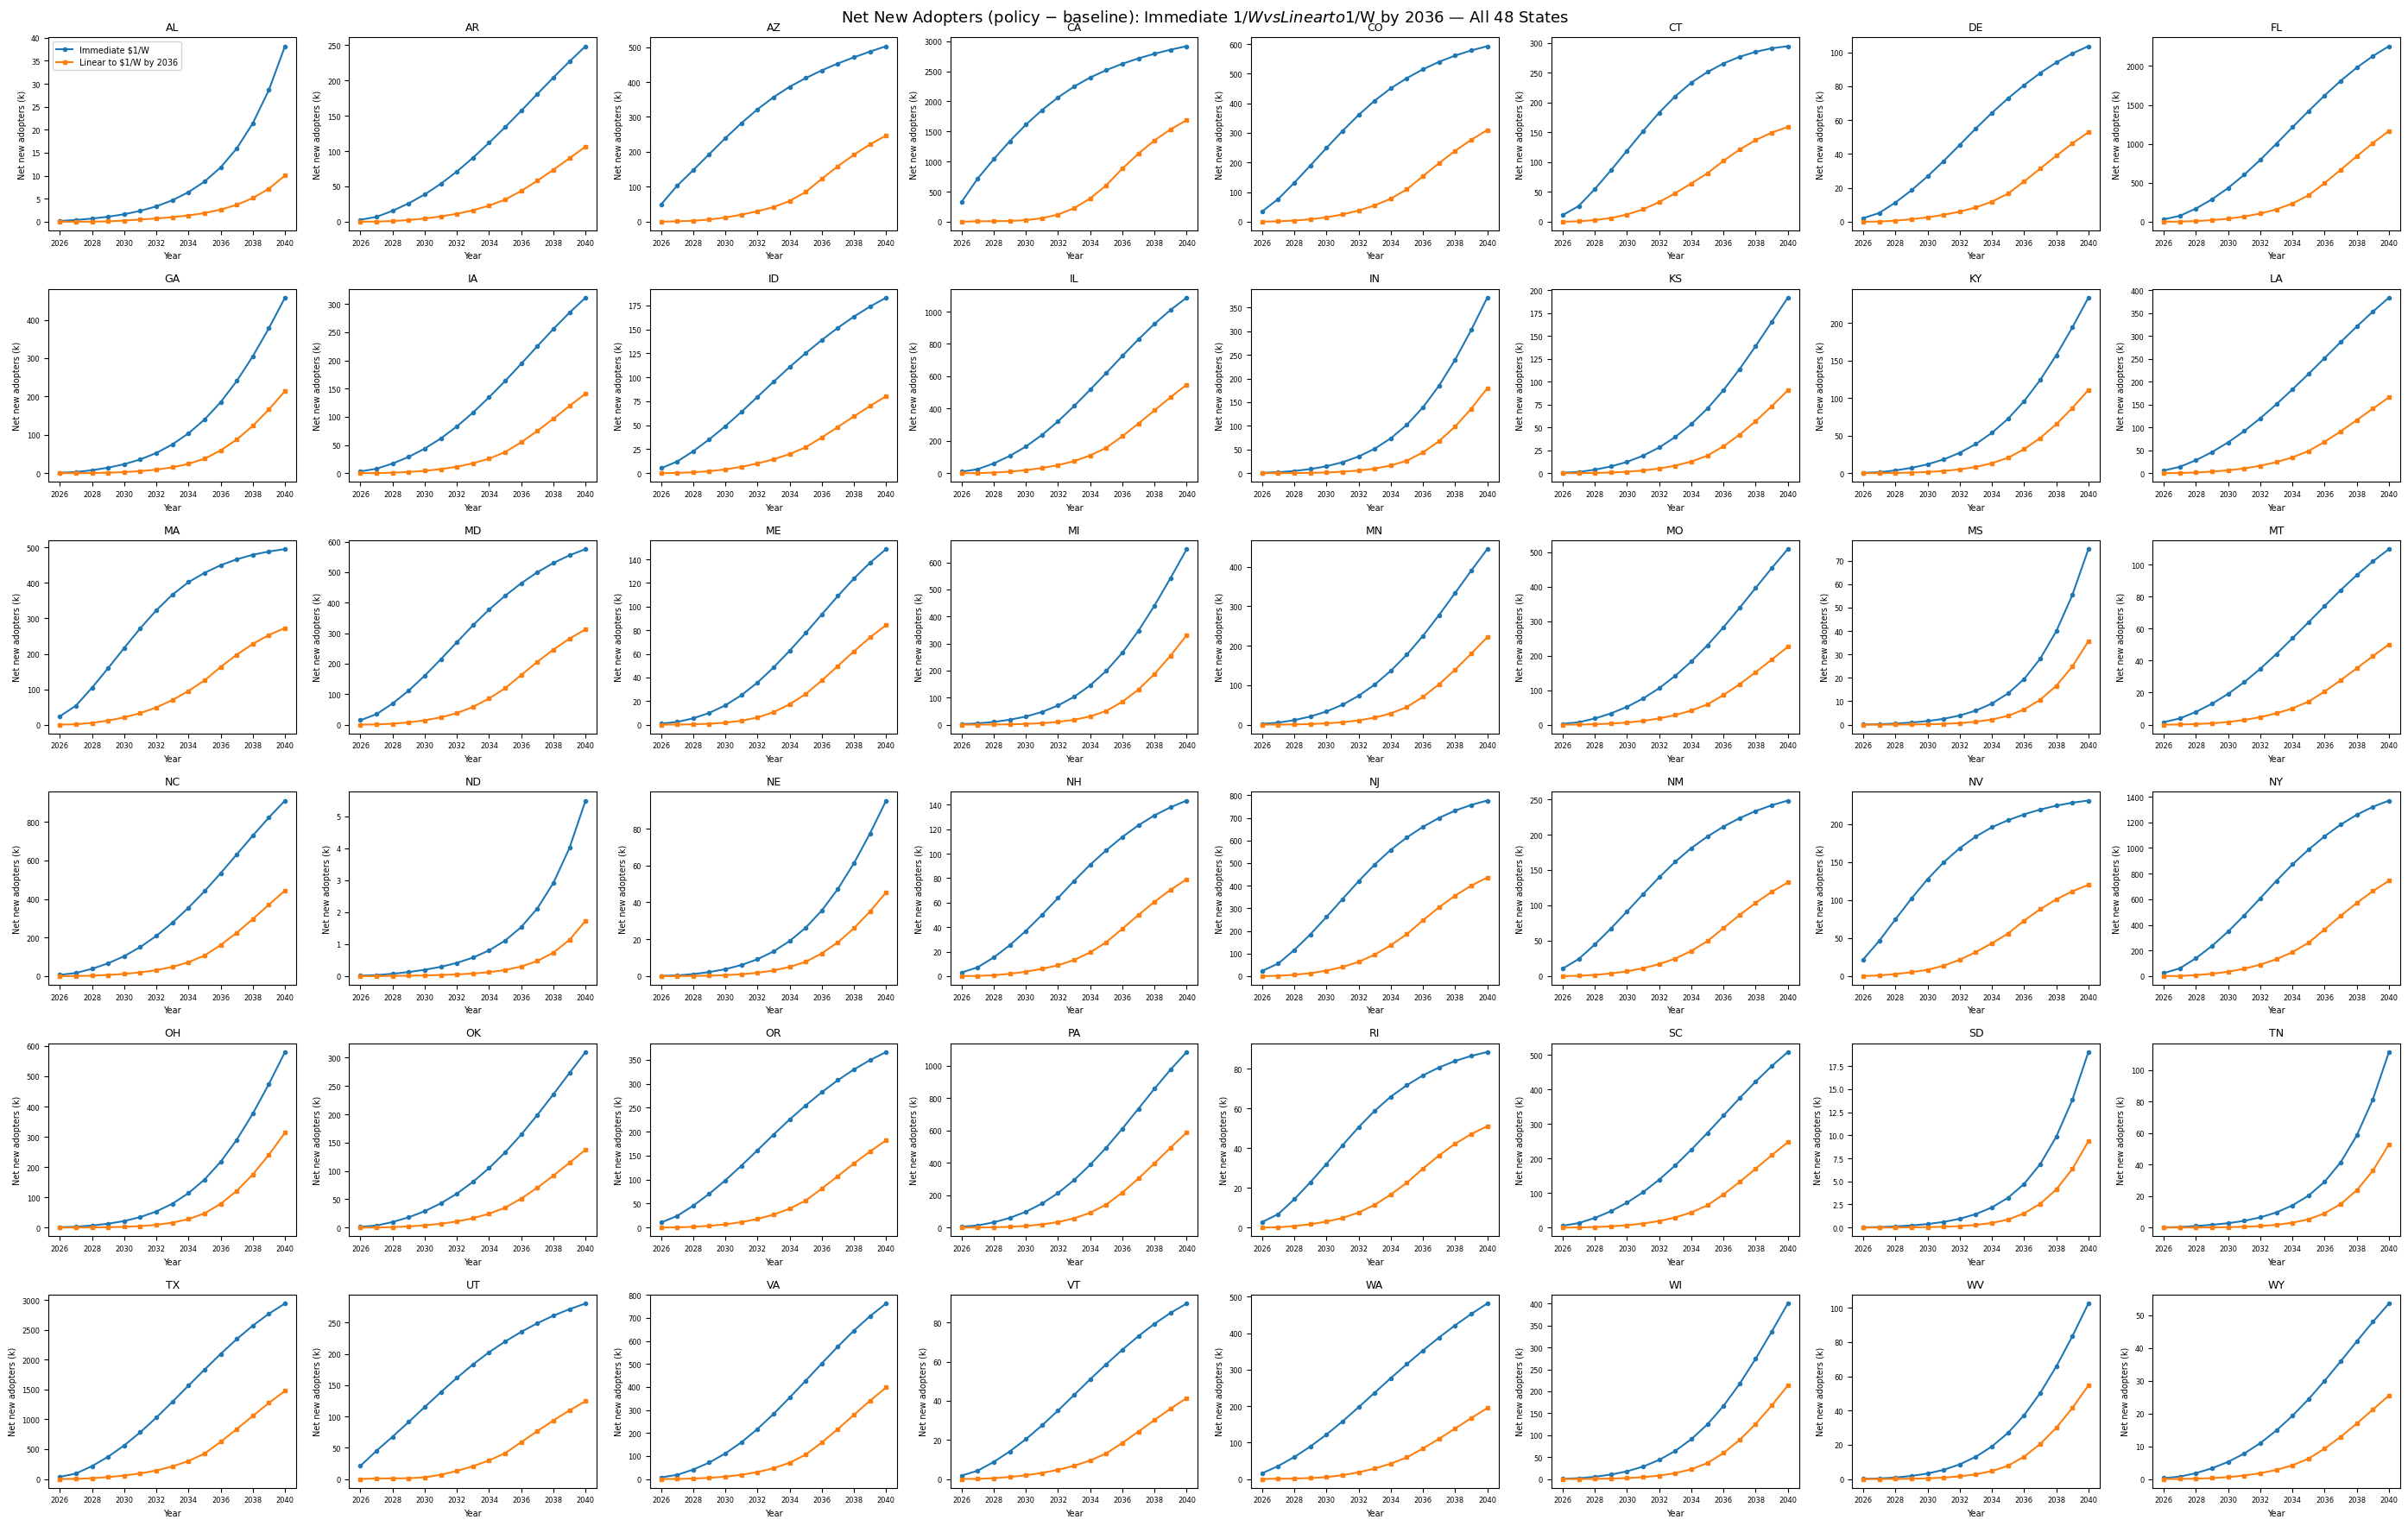

In [7]:
states_sorted = sorted(STATES)
n = len(states_sorted)
ncols = 8
nrows = (n + ncols - 1) // ncols  # 6 rows for 48 states
fig, axes = plt.subplots(nrows, ncols, figsize=(28, 18), sharey=False)
axes = axes.flatten()

for i, state in enumerate(states_sorted):
    sub = comp[comp["state_abbr"] == state]
    axes[i].plot(sub["year"], sub["number_of_adopters_old"] / 1e3, label=A_LABEL, marker="o", markersize=3)
    axes[i].plot(sub["year"], sub["number_of_adopters_new"] / 1e3, label=B_LABEL, marker="s", markersize=3)
    axes[i].set_title(state, fontsize=9)
    axes[i].set_xlabel("Year", fontsize=7)
    axes[i].set_ylabel("Net new adopters (k)", fontsize=7)
    axes[i].tick_params(labelsize=6)
    if i == 0:
        axes[i].legend(fontsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Net New Adopters (policy − baseline): {COMPARISON} — All 48 States", fontsize=13)
plt.tight_layout()
plt.show()

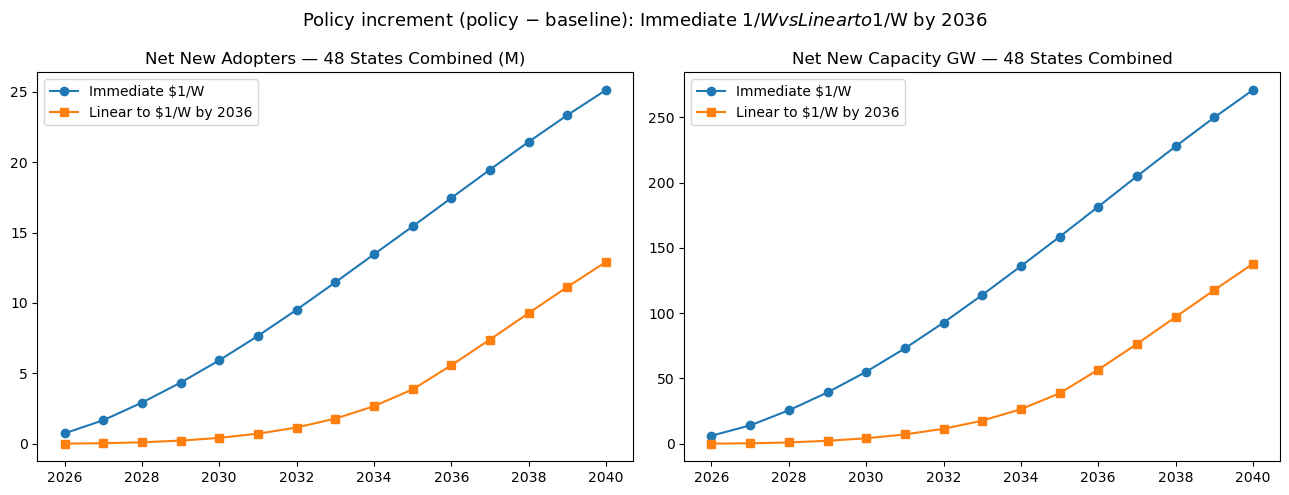


2040 totals across 48 states (policy − baseline increment):
  Metric                                       Immediate $1/W  Linear to $1/W by 2036    Change
  ────────────────────────────────────────────────────────────────────────────────────────────
  Adopters                                         25,139,167              12,917,566    -48.6%
  Capacity (GW)                                         271.0                   137.8    -49.2%
  Cumulative bill savings thru 2040                  334.0 $B                 93.5 $B    -72.0%
  Lifetime net savings (25yr)                          2.0 $T                  0.9 $T    -52.0%


In [8]:
# --- Aggregated across all 48 states ---
agg_old = old_inc.groupby("year")[["number_of_adopters", "system_kw_cum"]].sum().reset_index()
agg_new = new_inc.groupby("year")[["number_of_adopters", "system_kw_cum"]].sum().reset_index()
agg = agg_old.merge(agg_new, on="year", suffixes=("_old", "_new"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(agg["year"], agg["number_of_adopters_old"] / 1e6, label=A_LABEL, marker="o")
axes[0].plot(agg["year"], agg["number_of_adopters_new"] / 1e6, label=B_LABEL, marker="s")
axes[0].set_title("Net New Adopters — 48 States Combined (M)")
axes[0].legend()

axes[1].plot(agg["year"], agg["system_kw_cum_old"] / 1e6, label=A_LABEL, marker="o")
axes[1].plot(agg["year"], agg["system_kw_cum_new"] / 1e6, label=B_LABEL, marker="s")
axes[1].set_title("Net New Capacity GW — 48 States Combined")
axes[1].legend()

plt.suptitle(f"Policy increment (policy − baseline): {COMPARISON}", fontsize=13)
plt.tight_layout()
plt.show()

# --- Helper: policy - baseline increment summed across states ---
def sum_increment(df, states, col):
    if df is None or col not in df.columns:
        return None
    d = df[df["state_abbr"].isin(states)]
    pol = d[d["scenario"] == "policy"][col].sum()
    bas = d[d["scenario"] == "baseline"][col].sum()
    return pol - bas

def sum_increment_at_year(df, states, col, year=2040):
    if df is None or col not in df.columns:
        return None
    d = df[df["state_abbr"].isin(states) & (df["year"] == year)]
    pol = d[d["scenario"] == "policy"][col].sum()
    bas = d[d["scenario"] == "baseline"][col].sum()
    return pol - bas

row        = agg[agg["year"] == 2040].iloc[0]
adopters_old = row.number_of_adopters_old
adopters_new = row.number_of_adopters_new
cap_gw_old   = row.system_kw_cum_old / 1e6
cap_gw_new   = row.system_kw_cum_new / 1e6

old_cum  = sum_increment_at_year(old_cum_savings, STATES, "cumulative_bill_savings")
new_cum  = sum_increment_at_year(new_cum_savings, STATES, "cumulative_bill_savings")
old_life = sum_increment(old_lifetime, STATES, "lifetime_net_after_upfront_total")
new_life = sum_increment(new_lifetime, STATES, "lifetime_net_after_upfront_total")

def fmt(val, scale=1e9, unit="$B"):
    return f"{val/scale:.1f} {unit}" if val is not None else "—"

def pct(a, b):
    return f"{(b/a - 1)*100:+.1f}%" if a and b else "—"

w = max(14, len(A_LABEL), len(B_LABEL))
print(f"\n2040 totals across 48 states (policy − baseline increment):")
print(f"  {'Metric':<36} {A_LABEL:>{w}}  {B_LABEL:>{w}}  {'Change':>8}")
print(f"  {'─'*(38 + 2*w + 10)}")
print(f"  {'Adopters':<36} {adopters_old:>{w},.0f}  {adopters_new:>{w},.0f}  {pct(adopters_old, adopters_new):>8}")
print(f"  {'Capacity (GW)':<36} {cap_gw_old:>{w}.1f}  {cap_gw_new:>{w}.1f}  {pct(cap_gw_old, cap_gw_new):>8}")
print(f"  {'Cumulative bill savings thru 2040':<36} {fmt(old_cum):>{w}}  {fmt(new_cum):>{w}}  {pct(old_cum, new_cum):>8}")
print(f"  {'Lifetime net savings (25yr)':<36} {fmt(old_life, 1e12, '$T'):>{w}}  {fmt(new_life, 1e12, '$T'):>{w}}  {pct(old_life, new_life):>8}")

In [9]:
import glob

# --- County-level export (flexible) ---
# County-aggregated adopters / customers / developable% for each run listed.
# Output: {county_dir}/dollar_per_watt_agent_results_{key}.csv
COUNTY_EXPORT_RUNS = [A_KEY, B_KEY]   # which runs to export; edit freely
COLS = ["county_id", "state_abbr", "scenario", "year",
        "number_of_adopters", "customers_in_bin", "pct_of_bldgs_developable"]

def wavg_pct(g):
    w = g["customers_in_bin"]; v = g["pct_of_bldgs_developable"]
    mask = w.notna() & v.notna() & (w > 0)
    return (v[mask] * w[mask]).sum() / w[mask].sum() if mask.any() else v.mean()

for key in COUNTY_EXPORT_RUNS:
    run  = RUNS[key]
    rdir = os.path.join(DRIVE, run["county_dir"])
    chunks = []
    for scenario in ["baseline", "policy"]:
        pattern = os.path.join(rdir, "*", run["run_id"], f"{scenario}.csv")
        files = sorted(glob.glob(pattern))
        print(f"[{key}] {scenario}: {len(files)} state files")
        for f in files:
            df = pd.read_csv(f, usecols=COLS, low_memory=False)
            df["scenario"] = scenario
            chunks.append(df)
    if not chunks:
        print(f"[{key}] no files found — skipping\n")
        continue
    agents = pd.concat(chunks, ignore_index=True)
    county = (
        agents.groupby(["county_id", "state_abbr", "scenario", "year"], as_index=False)
        .apply(lambda g: pd.Series({
            "number_of_adopters":       g["number_of_adopters"].sum(),
            "customers_in_bin":         g["customers_in_bin"].sum(),
            "pct_of_bldgs_developable": wavg_pct(g),
        }), include_groups=False)
        .reset_index(drop=True)
        .sort_values(["state_abbr", "county_id", "scenario", "year"])
    )
    out_path = os.path.join(rdir, f"dollar_per_watt_agent_results_{key}.csv")
    county.to_csv(out_path, index=False)
    print(f"[{key}] saved {len(county):,} rows, {county['county_id'].nunique()} counties → {out_path}\n")

[updated_immediate] baseline: 48 state files
[updated_immediate] policy: 48 state files
[updated_immediate] saved 93,060 rows, 3102 counties → /Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025/Results/Updated tariffs/dollar_per_watt_agent_results_updated_immediate.csv

[linear_to_1w] baseline: 48 state files
[linear_to_1w] policy: 48 state files
[linear_to_1w] saved 93,060 rows, 3102 counties → /Users/wael/Library/CloudStorage/GoogleDrive-wael@permitpower.org/Shared drives/PP (All)/Research/$1 watt solar/2025/Results/Updated tariffs/dollar_per_watt_agent_results_linear_to_1w.csv

